#<font color= 'Blue'><font size= 18> Assignment 3</font></font>
---
1. Load the wine dataset from sklearn.datasets using import load_wine and apply PCA and TSNE on this dataset.



In [59]:
# Import the libraries and functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [60]:
#Data
wine = datasets.load_wine()
wine.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

# <font color="turquoise"> **1. PCA using sklearn**
---

In [61]:
# --------------------------------------------
# Step 1: Load Dataset
# --------------------------------------------
X = wine.data
Y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

wine_df = pd.DataFrame(X, columns=feature_names)
wine_df['class'] = Y

print(wine_df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  class  
0           

In [62]:
# --------------------------------------------
# Step 2: Standardize the data
# --------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --------------------------------------------
# Step 3: Apply PCA() function to the scaled data
# --------------------------------------------
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_varience = pca.explained_variance_ratio_

cumulative_variance = np.cumsum(explained_varience)

print("\nExplained Variance Ratio: \n", explained_varience)
print("\n")
print("Cumulative Explained Variance: \n", cumulative_variance)


Explained Variance Ratio: 
 [0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


Cumulative Explained Variance: 
 [0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


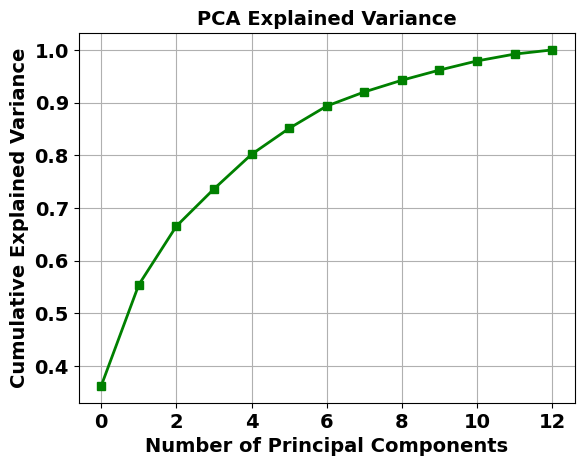

In [63]:
# --------------------------------------------
# Step 4: Plot cumulative variance
# --------------------------------------------
plt.figure()

plt.plot(cumulative_variance, marker='s', linewidth=2, color='green')

##Labels, titles
plt.xlabel("Number of Principal Components", fontsize=14, fontweight='bold')
plt.ylabel("Cumulative Explained Variance", fontsize=14, fontweight='bold')
plt.title("PCA Explained Variance", fontsize=14, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.grid(True)
plt.show()

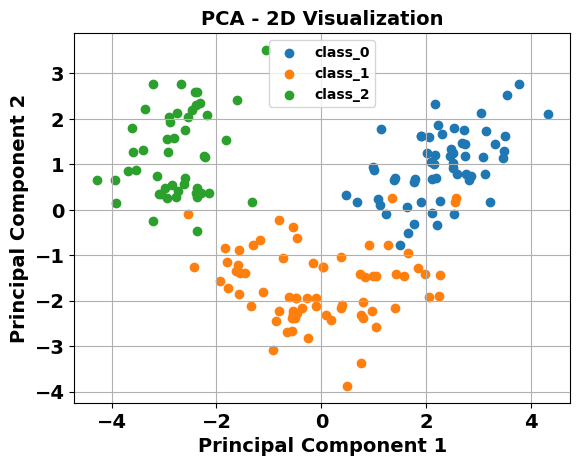

In [64]:
# --------------------------------------------
# Step 5: PCA with optimal components (2D)
# --------------------------------------------
pca_2d = PCA(n_components= 2)
X_pca_2 = pca_2d.fit_transform(X_scaled)

plt.figure()
for i, target in enumerate(target_names):
  plt.scatter(X_pca_2[Y==i, 0], X_pca_2[Y==i, 1], label=target)

##Labels, Titles
plt.xlabel("Principal Component 1", fontsize=14, fontweight='bold')
plt.ylabel("Principal Component 2", fontsize=14, fontweight='bold')
plt.title("PCA - 2D Visualization", fontsize=14, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.legend(fontsize=14, prop={'weight': 'bold'}, loc='upper center')
plt.grid(True)
plt.show()

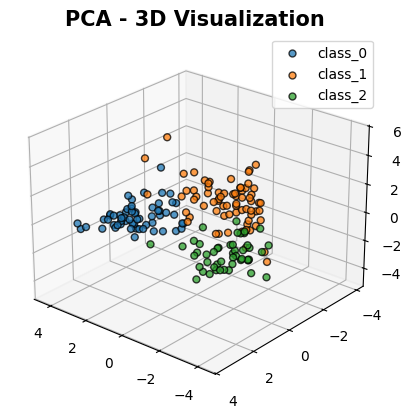

In [65]:
# Apply PCA
pca_3d = PCA(n_components=3)
X_pca_3 = pca_3d.fit_transform(X_scaled)

# Create 3D figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot each class
for i, target in enumerate(target_names):
    ax.scatter(
        X_pca_3[Y == i, 0],
        X_pca_3[Y == i, 1],
        X_pca_3[Y == i, 2],
        s=25,
        alpha=0.75,
        edgecolor='k',
        label=target
    )

# Title
ax.set_title("PCA - 3D Visualization", fontsize=15, fontweight='bold')

# Adjust viewing angle
ax.view_init(elev=25, azim=130)

ax.legend()
plt.show()

# <font color="turquoise"> **2. TSNE using sklearn**
---

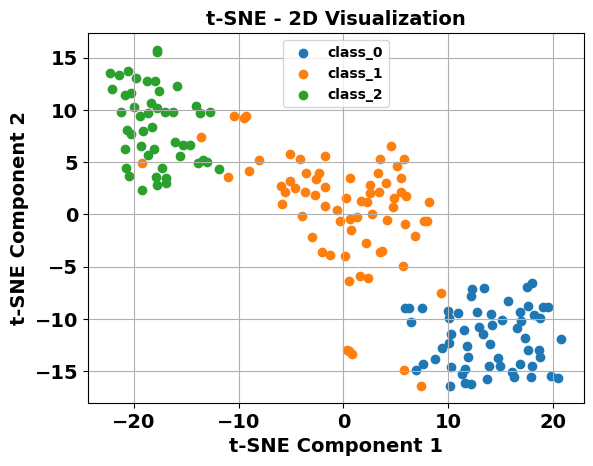

In [66]:
tsne = TSNE(n_components=2, perplexity=20, random_state=None)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure()
for i, target in enumerate(target_names):
    plt.scatter(X_tsne[Y==i, 0], X_tsne[Y==i, 1], label=target)

##Set the labels, titles, etc.
plt.xlabel("t-SNE Component 1", fontsize=14, fontweight='bold')
plt.ylabel("t-SNE Component 2", fontsize=14, fontweight='bold')
plt.title("t-SNE - 2D Visualization", fontsize=14, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.legend(fontsize=14, prop={'weight': 'bold'}, loc='upper center')
plt.grid(True)
plt.show()